# TEP 工业世界模型：从过程数据到控制规划

本教程以 Tennessee Eastman Process（TEP）为对象，构建一个动作条件的 JEPA 工业世界模型，并完成数据生成、表征学习、状态预测、反事实推演和闭环控制规划。

## TEP数据集概况

工具导入

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from tep import TEPSimulator

project_root = Path.cwd()
if not (project_root / "utils").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from data.data_gen import TEPDataGenerator, load_data_config
from engine.generation import build_generation_plan, generate_dataset
from utils.visualization import (
    plot_counterfactual_comparison,
    plot_key_variable_lines,
    plot_trajectory_overview,
    plot_variable_heatmap,
    plot_vector_bar,
)

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind", font_scale=1.05)

轨迹生成

In [2]:
# 生成一条 1 小时、1 秒采样的正常闭环轨迹
seed = 42
simulator = TEPSimulator(random_seed=seed, backend="python")
result = simulator.simulate(duration_hours=1.0, record_interval=1)

# 设置列名
measurement_columns = [
    f"XMEAS({i}) {name}"
    for i, name in enumerate(simulator.get_measurement_names(), start=1)
]
action_columns = [
    f"XMV({i}) {name}"
    for i, name in enumerate(simulator.get_mv_names(), start=1)
]

# 在线可用的过程轨迹：时间、41 个测量变量和 12 个操纵变量
tep_trajectory = pd.concat(
    [
        pd.DataFrame({"time_hours": result.time}),
        pd.DataFrame(result.measurements, columns=measurement_columns),
        pd.DataFrame(result.manipulated_vars, columns=action_columns),
    ],
    axis=1,
)

# 50 维内部状态属于仿真器特权信息，单独保存
tep_states = pd.DataFrame(
    result.states,
    columns=[f"STATE({i})" for i in range(1, result.states.shape[1] + 1)],
)

print(f"轨迹采样点数: {len(tep_trajectory)}")
print(f"过程轨迹形状: {tep_trajectory.shape}")
print(f"内部状态形状: {tep_states.shape}")
print(f"是否触发停车: {result.shutdown}")
tep_trajectory.head()

轨迹采样点数: 3601
过程轨迹形状: (3601, 54)
内部状态形状: (3601, 50)
是否触发停车: False


,time_hours,XMEAS(1) A Feed (stream 1),XMEAS(2) D Feed (stream 2),XMEAS(3) E Feed (stream 3),XMEAS(4) A and C Feed (stream 4),XMEAS(5) Recycle Flow (stream 8),XMEAS(6) Reactor Feed Rate (stream 6),XMEAS(7) Reactor Pressure,XMEAS(8) Reactor Level,XMEAS(9) Reactor Temperature,...,XMV(3) A Feed Flow (stream 1),XMV(4) A and C Feed Flow (stream 4),XMV(5) Compressor Recycle Valve,XMV(6) Purge Valve (stream 9),XMV(7) Separator Pot Liquid Flow,XMV(8) Stripper Liquid Product Flow,XMV(9) Stripper Steam Valve,XMV(10) Reactor Cooling Water Flow,XMV(11) Condenser Cooling Water Flow,XMV(12) Agitator Speed
0,0.000000,0.250521,3664.038885,4509.268390,9.347742,26.902440,42.338849,2705.000000,75.000000,120.400000,...,24.643558,61.301921,22.210000,40.063747,38.100344,46.534156,47.445735,41.105813,18.113491,50.0
1,0.000278,0.250521,3664.038885,4509.268390,9.347742,26.902440,42.338849,2705.000000,75.000000,120.400000,...,26.263874,60.595414,22.210276,40.064106,38.100344,46.534156,47.445929,41.106100,18.114131,50.0
2,0.000556,0.252494,3632.402846,4504.619387,9.275586,26.680047,42.599894,2704.521753,75.050384,120.403353,...,26.263874,60.595414,22.210276,40.064106,38.100344,46.534156,47.445929,41.106100,18.114131,50.0
3,0.000833,0.253498,3673.271109,4471.339448,9.258792,27.000335,42.395277,2704.882467,75.199208,120.410779,...,26.263874,60.595414,22.210276,40.064106,38.100344,46.534156,47.445929,41.106100,18.114131,50.0
4,0.001111,0.255614,3641.960057,4436.460851,9.367677,27.140838,42.559449,2705.321432,75.428329,120.395700,...,25.978932,61.178694,22.271806,24.563023,32.351885,47.263719,47.363078,41.113061,18.077483,50.0


### XMEAS 传感器变量

XMEAS 数组维数: 2
XMEAS 形状: (3601, 41)
样本数: 3601
传感器变量数: 41


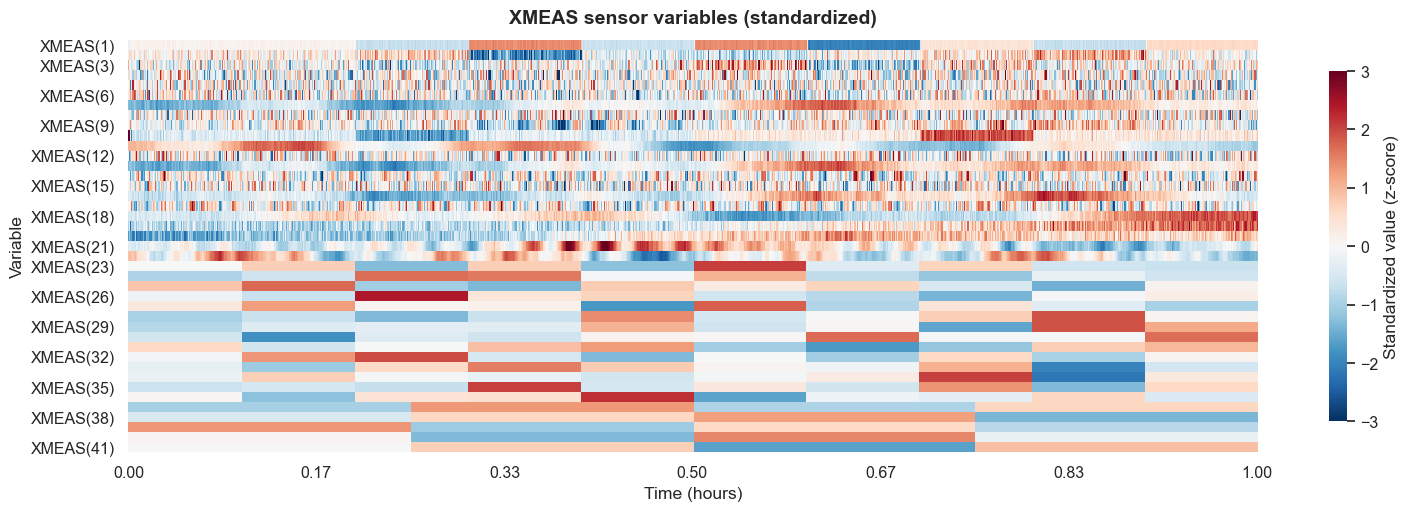

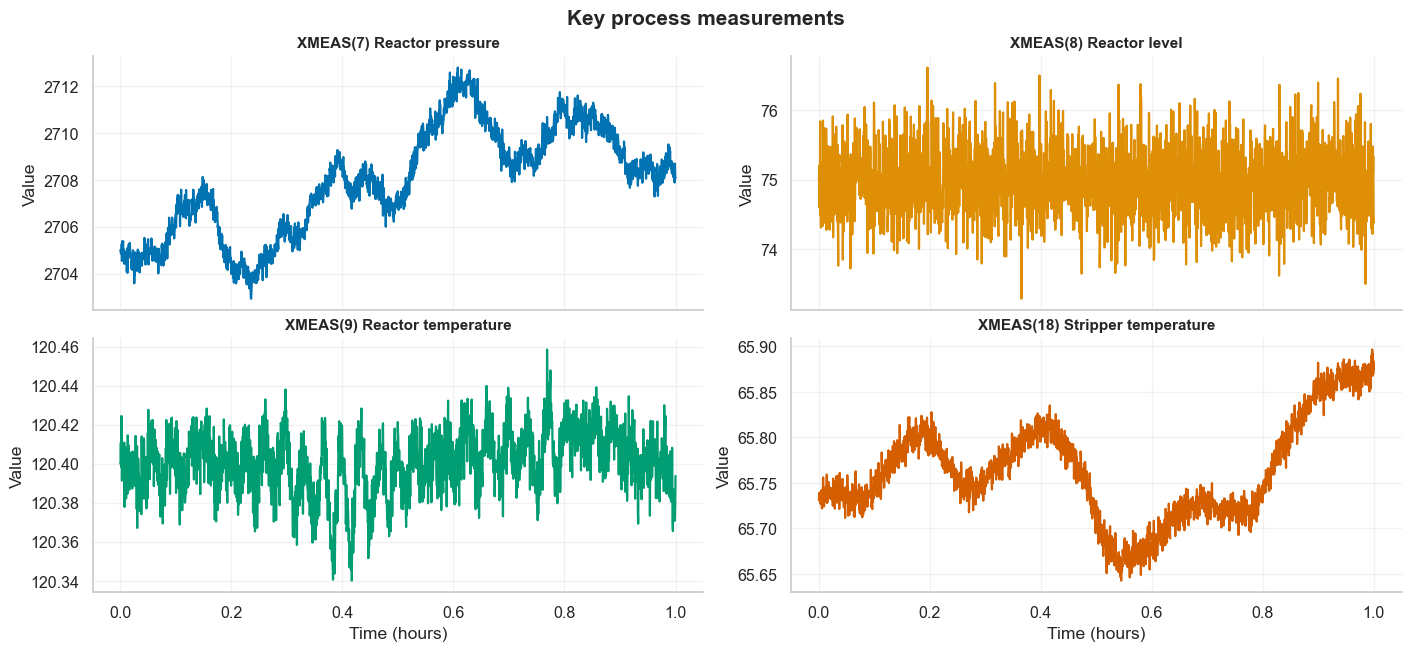

In [3]:
xmeas = pd.DataFrame(result.measurements, columns=measurement_columns)

print(f"XMEAS 数组维数: {result.measurements.ndim}")
print(f"XMEAS 形状: {result.measurements.shape}")
print(f"样本数: {result.measurements.shape[0]}")
print(f"传感器变量数: {result.measurements.shape[1]}")

plot_variable_heatmap(
    result.time,
    xmeas,
    labels=[f"XMEAS({i})" for i in range(1, xmeas.shape[1] + 1)],
    title="XMEAS sensor variables (standardized)",
)
plt.show()

plot_key_variable_lines(
    result.time,
    xmeas,
    indices=[6, 7, 8, 17],
    labels=[
        "XMEAS(7) Reactor pressure",
        "XMEAS(8) Reactor level",
        "XMEAS(9) Reactor temperature",
        "XMEAS(18) Stripper temperature",
    ],
    title="Key process measurements",
)
plt.show()

### XMV 操纵变量

XMV 数组维数: 2
XMV 形状: (3601, 12)
样本数: 3601
操纵变量数: 12


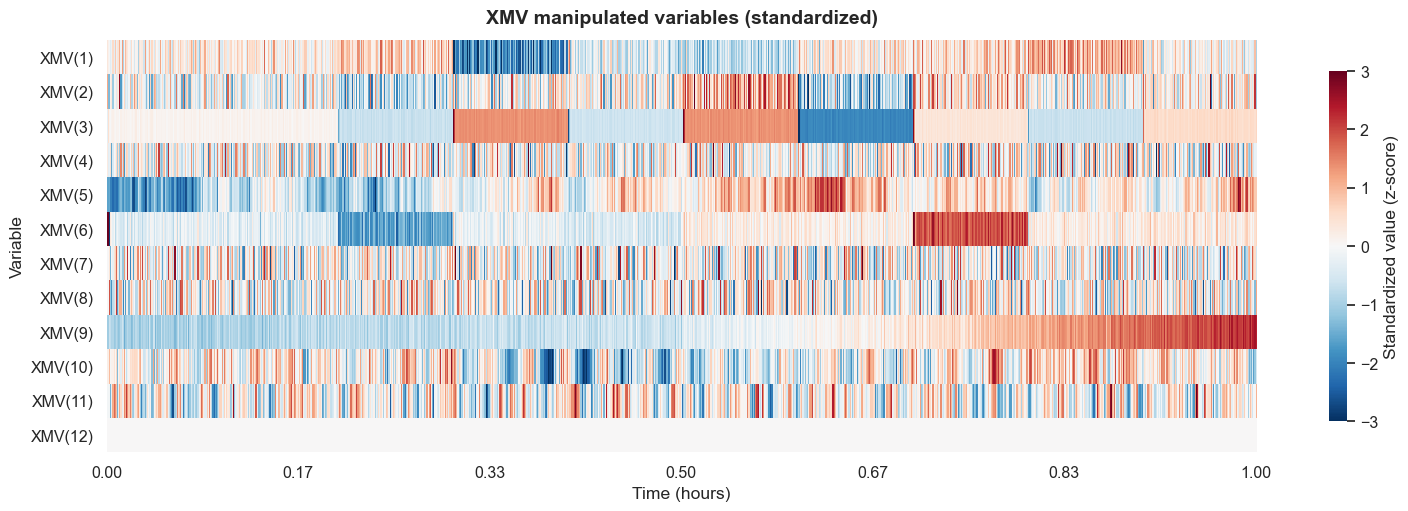

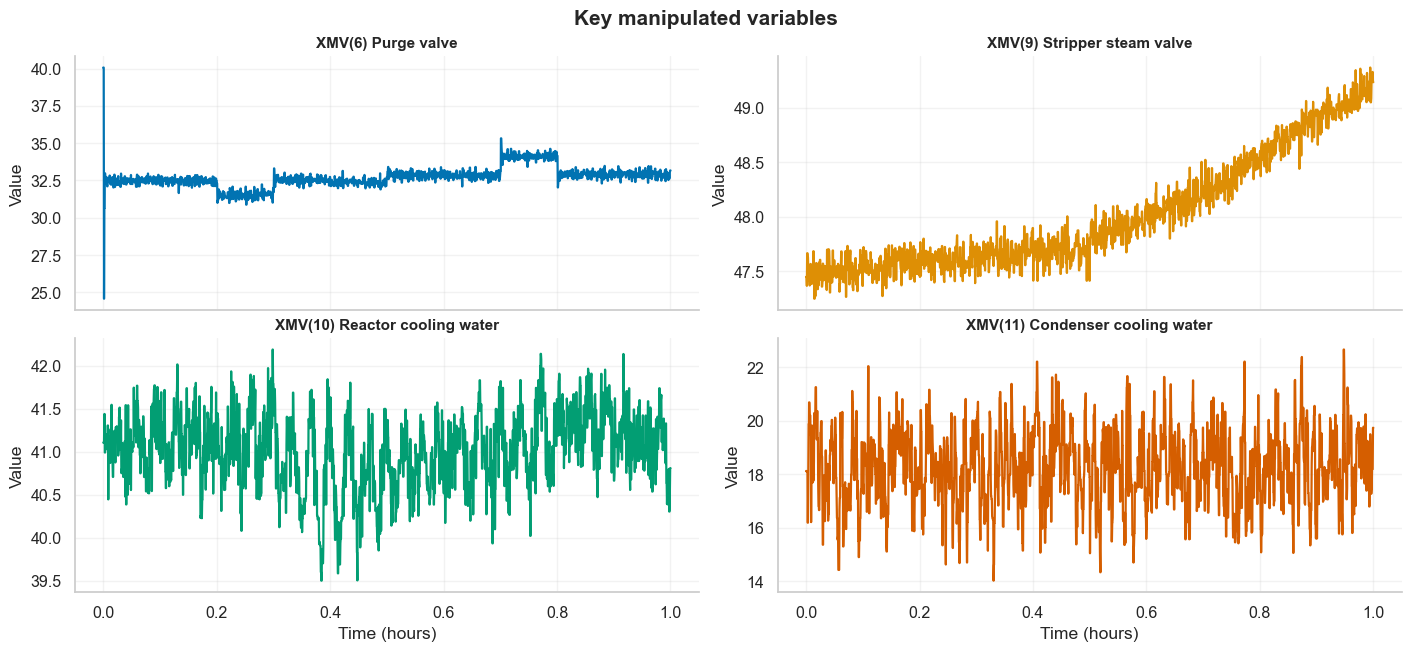

In [4]:
xmv = pd.DataFrame(result.manipulated_vars, columns=action_columns)

print(f"XMV 数组维数: {result.manipulated_vars.ndim}")
print(f"XMV 形状: {result.manipulated_vars.shape}")
print(f"样本数: {result.manipulated_vars.shape[0]}")
print(f"操纵变量数: {result.manipulated_vars.shape[1]}")

plot_variable_heatmap(
    result.time,
    xmv,
    labels=[f"XMV({i})" for i in range(1, xmv.shape[1] + 1)],
    title="XMV manipulated variables (standardized)",
)
plt.show()

plot_key_variable_lines(
    result.time,
    xmv,
    indices=[5, 8, 9, 10],
    labels=[
        "XMV(6) Purge valve",
        "XMV(9) Stripper steam valve",
        "XMV(10) Reactor cooling water",
        "XMV(11) Condenser cooling water",
    ],
    title="Key manipulated variables",
)
plt.show()

### 内部状态变量

内部状态数组维数: 2
内部状态形状: (3601, 50)
样本数: 3601
内部状态变量数: 50


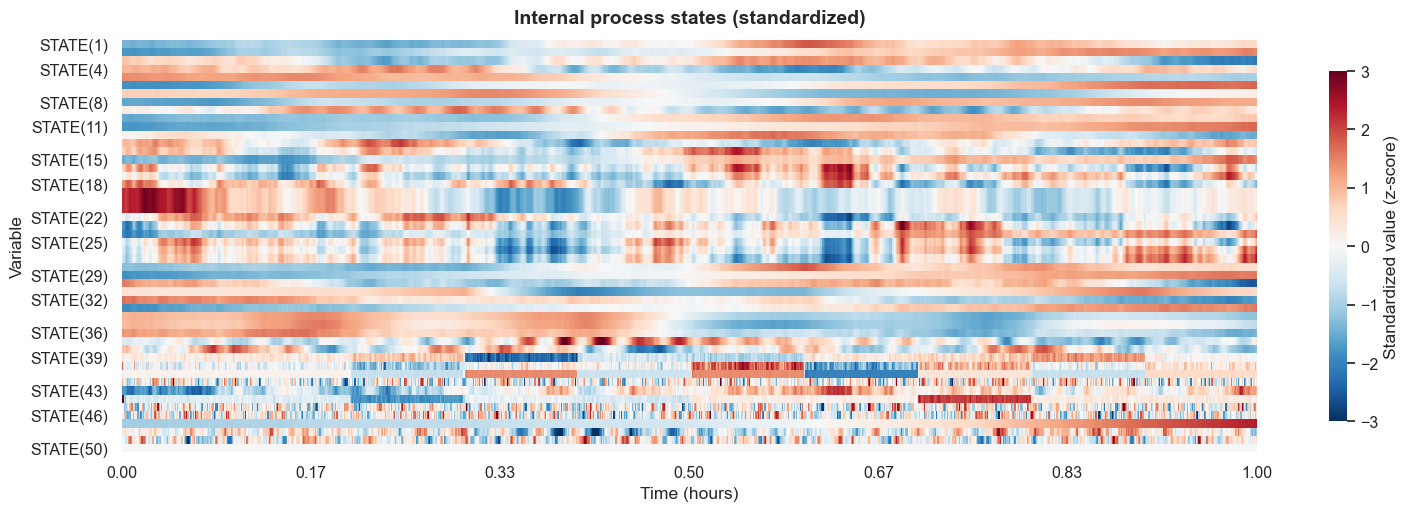

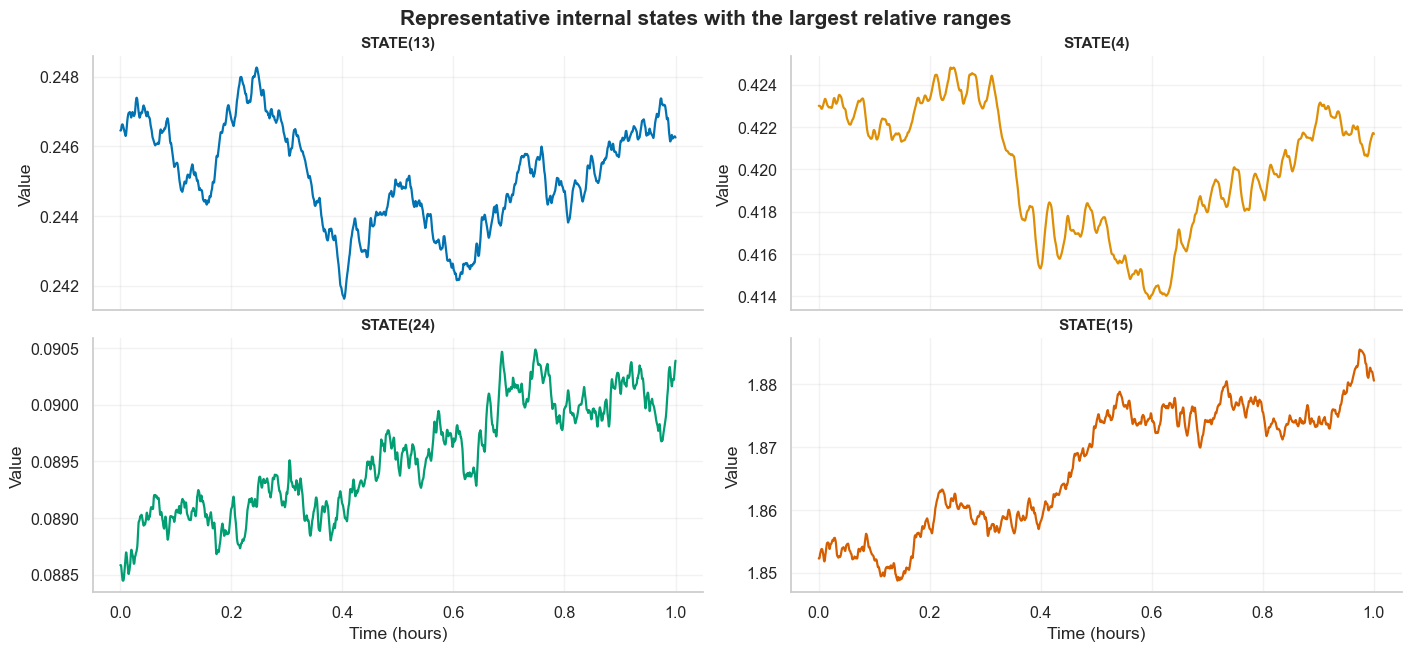

In [5]:
print(f"内部状态数组维数: {result.states.ndim}")
print(f"内部状态形状: {result.states.shape}")
print(f"样本数: {result.states.shape[0]}")
print(f"内部状态变量数: {result.states.shape[1]}")

plot_variable_heatmap(
    result.time,
    tep_states,
    labels=[f"STATE({i})" for i in range(1, tep_states.shape[1] + 1)],
    title="Internal process states (standardized)",
)
plt.show()

# 从前 38 个过程状态中选择相对变化幅度最大的 4 个，避免与末尾阀位状态重复
process_states = tep_states.iloc[:, :38]
relative_range = (process_states.max() - process_states.min()) / (process_states.mean().abs() + 1e-8)
key_state_indices = np.argsort(relative_range.to_numpy())[-4:][::-1]
key_state_labels = [process_states.columns[i] for i in key_state_indices]

plot_key_variable_lines(
    result.time,
    tep_states,
    indices=key_state_indices,
    labels=key_state_labels,
    title="Representative internal states with the largest relative ranges",
)
plt.show()

### 控制器设定值（调节器变量）

控制器类型: DecentralizedController
设定值数组维数: 1
设定值形状: (20,)
说明: 设定值是控制器参数，不包含时间维，因此不随时间变化。


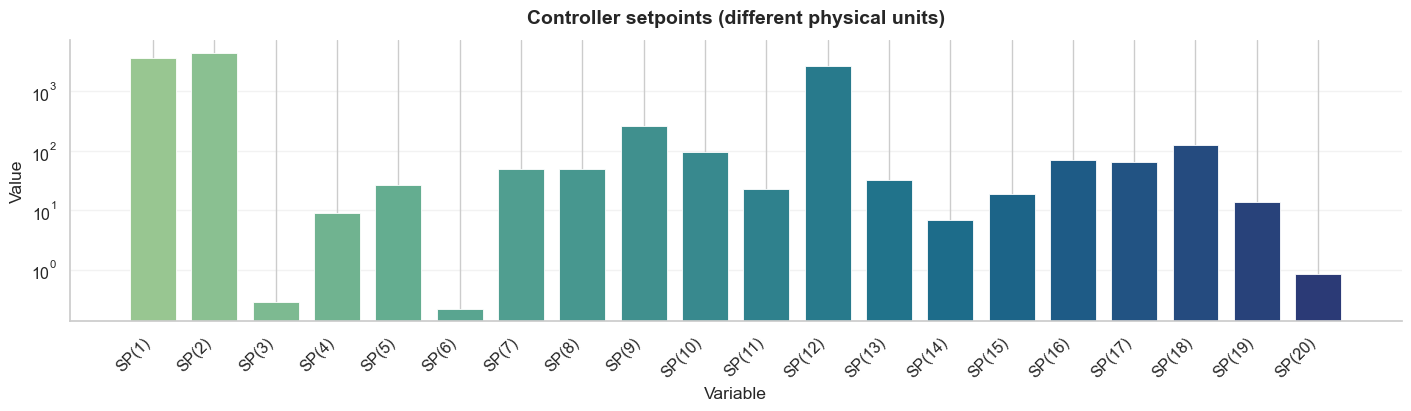

In [6]:
controller_setpoints = np.asarray(simulator.controller.setpoints)
setpoint_table = pd.DataFrame(
    {
        "controller": [f"SP({i})" for i in range(1, len(controller_setpoints) + 1)],
        "setpoint": controller_setpoints,
    }
)

print(f"控制器类型: {type(simulator.controller).__name__}")
print(f"设定值数组维数: {controller_setpoints.ndim}")
print(f"设定值形状: {controller_setpoints.shape}")
print("说明: 设定值是控制器参数，不包含时间维，因此不随时间变化。")

plot_vector_bar(
    controller_setpoints,
    labels=setpoint_table["controller"],
    title="Controller setpoints (different physical units)",
    log_scale=True,
)
plt.show()

## 世界模型的状态与动作

**观测状态**采用 `XMEAS(41) + XMV(12)`，共 53 维。XMEAS 描述过程测量，XMV 描述底层控制器实际施加的操纵量；模型使用一段历史观测推断未直接观测的过程和控制器状态。

**动作**采用可由上层规划器设定的 11 个外部 SP：

- 基础动作：SP13、SP14、SP15、SP17、SP18、SP19、SP20。
- 扩展动作：SP5、SP7、SP8、SP11，分别用于循环负荷、分离器液位、汽提塔液位和生产负荷调节。

SP1、SP2、SP3、SP4、SP6、SP9、SP10、SP16由串级控制器动态生成，属于内部控制器状态，不作为独立动作。规划器联合优化11个外部SP，并通过动作边界、变化率和偏离默认值惩罚，使不需要调整的SP自然保持稳定。

世界模型学习：`历史(XMEAS, XMV) + 外部SP动作 → 未来(XMEAS, XMV)`。

## 轨迹数据生成策略

| 轨迹类型 | 典型设置 | 主要用途 |
|---|---|---|
| 固定SP | 全程不改变外部SP | 基础过程动力学 |
| 单动作 | 单个SP发生一次变化 | 单变量动作响应 |
| 多动作 | 多时刻改变一个或多个SP | 动作耦合与目标转移 |
| 干扰 | 在固定SP或动作轨迹上加入IDV | 异常与恢复动力学 |
| 超限 | 动作使变量越过设定的软安全边界 | 边界和异常后果 |

单条动作轨迹可以只覆盖部分SP，批量数据集再统一检查11维动作覆盖。以下单元格只展示轨迹信息与曲线；结构质量门、完整性检查和数据集覆盖检查在批量生成入库时统一执行。

In [7]:
# 读取统一配置；辅助函数仅负责展示轨迹摘要和曲线。
data_config = load_data_config(project_root / "configs/config.yaml")

def show_trajectory(trajectory, config, title):
    active_idvs = np.flatnonzero(trajectory.disturbances.max(axis=0)) + 1
    summary = pd.DataFrame([{
        "type": trajectory.trajectory_type,
        "outcome": trajectory.outcome,
        "duration (h)": round(float(trajectory.time[-1]), 3),
        "transitions": len(trajectory.actions),
        "observation shape": str(trajectory.observations.shape),
        "action shape": str(trajectory.actions.shape),
        "changed SPs": str(list(trajectory.metadata["changed_action_sp_numbers"])),
        "active IDVs": str(active_idvs.tolist()),
        "shutdown": trajectory.shutdown,
    }])
    display(summary)
    plot_trajectory_overview(
        trajectory,
        action_sp_numbers=config["action_sp_numbers"],
        title=title,
    )
    plt.show()

### 1. 固定SP轨迹

预热至稳定工况后，所有外部SP保持不变，用于展示正常闭环运行下的基础动力学。

,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,fixed_sp,normal,1.0,3600,"(3601, 53)","(3600, 11)",[],[],False


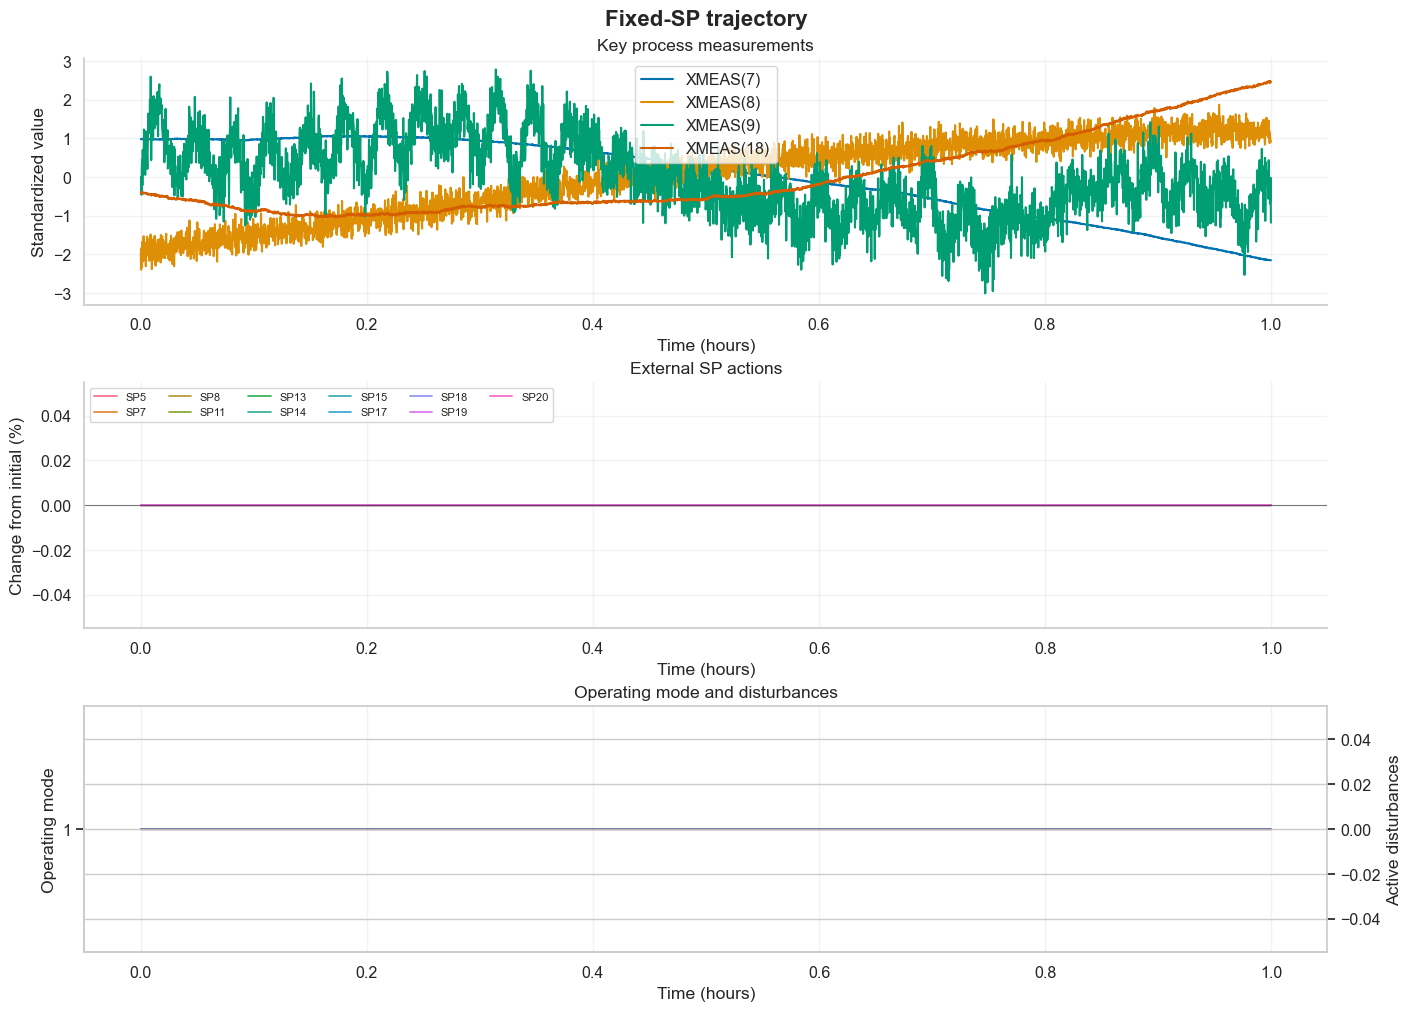

In [8]:
# 预热后不施加动作或干扰，记录正常闭环运行过程。
fixed_config = {
    **data_config,
    "warmup_hours": 3.0,
    "duration_hours": 1.0,
    "mode_events": [],
    "action_events": [],
    "disturbance_events": [],
}
fixed_trajectory = TEPDataGenerator(fixed_config).generate_trajectory()
show_trajectory(fixed_trajectory, fixed_config, "Fixed-SP trajectory")

### 2. 单动作轨迹

仅改变反应器温度设定值SP18，其他动作保持不变，用于观察清晰的单动作响应及其传播过程。

,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,action,limit_exceeded,3.0,10800,"(10801, 53)","(10800, 11)",[18],[],False


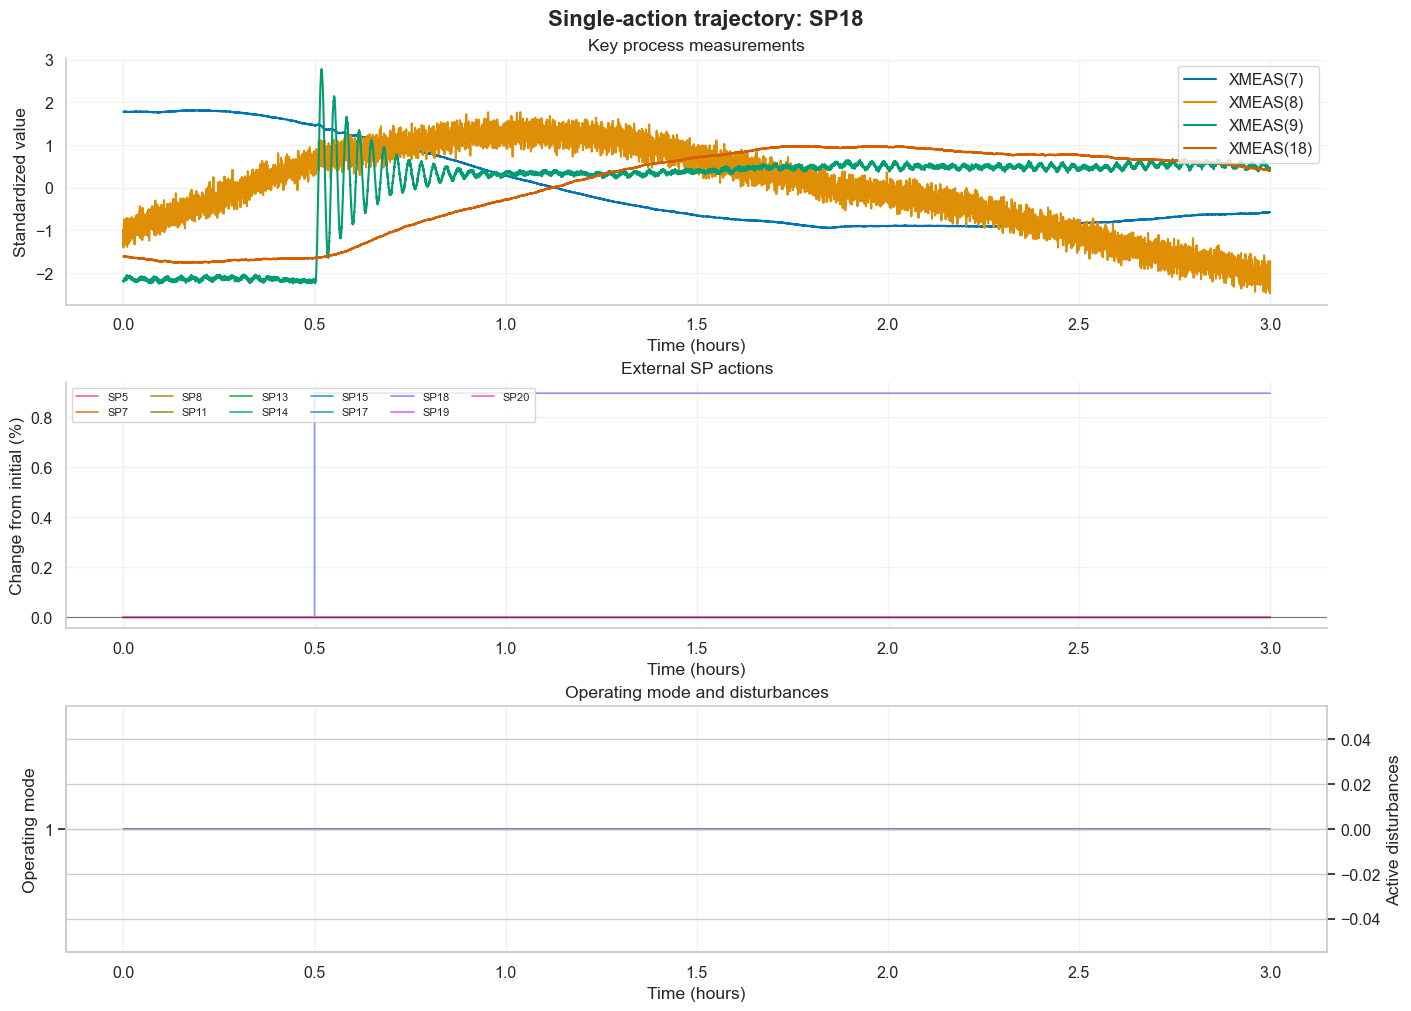

In [9]:
# 0.5小时将SP18阶跃到124°C，此后保持该设定值。
single_action_config = {
    **data_config,
    "warmup_hours": 3.0,
    "duration_hours": 3.0,
    "mode_events": [],
    "disturbance_events": [],
    "action_events": [
        {"time_hours": 0.50, "values": {"SP18": 124.0}},
    ],
}
single_action_trajectory = TEPDataGenerator(single_action_config).generate_trajectory()
show_trajectory(
    single_action_trajectory,
    single_action_config,
    "Single-action trajectory: SP18",
)

### 3. 多动作轨迹

在不同时刻改变SP5、SP7、SP11、SP18和SP20，形成多变量耦合的显著目标转移。单条轨迹无需覆盖全部11维动作。

,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,action,recovered,4.0,14400,"(14401, 53)","(14400, 11)","[5, 7, 11, 18, 20]",[],False


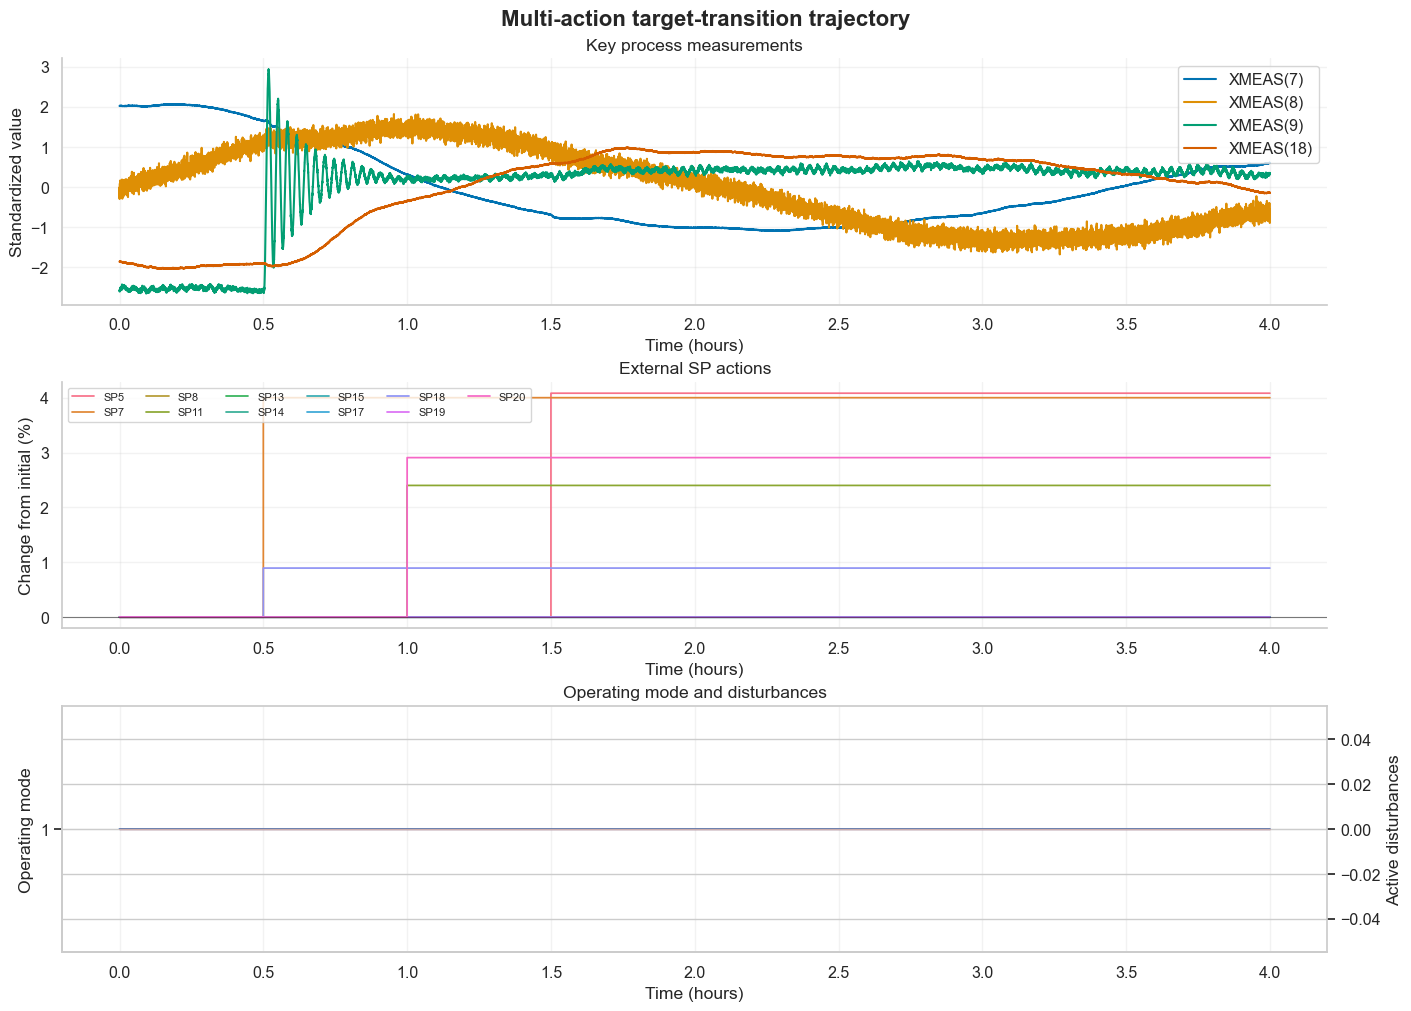

In [10]:
# 在多个时刻更新部分SP；未更新的SP继续保持当前值。
multi_action_config = {
    **data_config,
    "warmup_hours": 3.0,
    "duration_hours": 4.0,
    "mode_events": [],
    "disturbance_events": [],
    "action_events": [
        {"time_hours": 0.50, "values": {"SP18": 124.0, "SP7": 52.0}},
        {"time_hours": 1.00, "values": {"SP20": 0.86, "SP11": 23.5}},
        {"time_hours": 1.50, "values": {"SP5": 28.0}},
    ],
}
multi_action_trajectory = TEPDataGenerator(multi_action_config).generate_trajectory()
show_trajectory(
    multi_action_trajectory,
    multi_action_config,
    "Multi-action target-transition trajectory",
)

### 4. 干扰与恢复轨迹

在固定SP条件下开启IDV(1)，保持1.5小时后关闭，并继续记录恢复过程。

,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,disturbance,recovered,4.0,14400,"(14401, 53)","(14400, 11)",[],[1],False


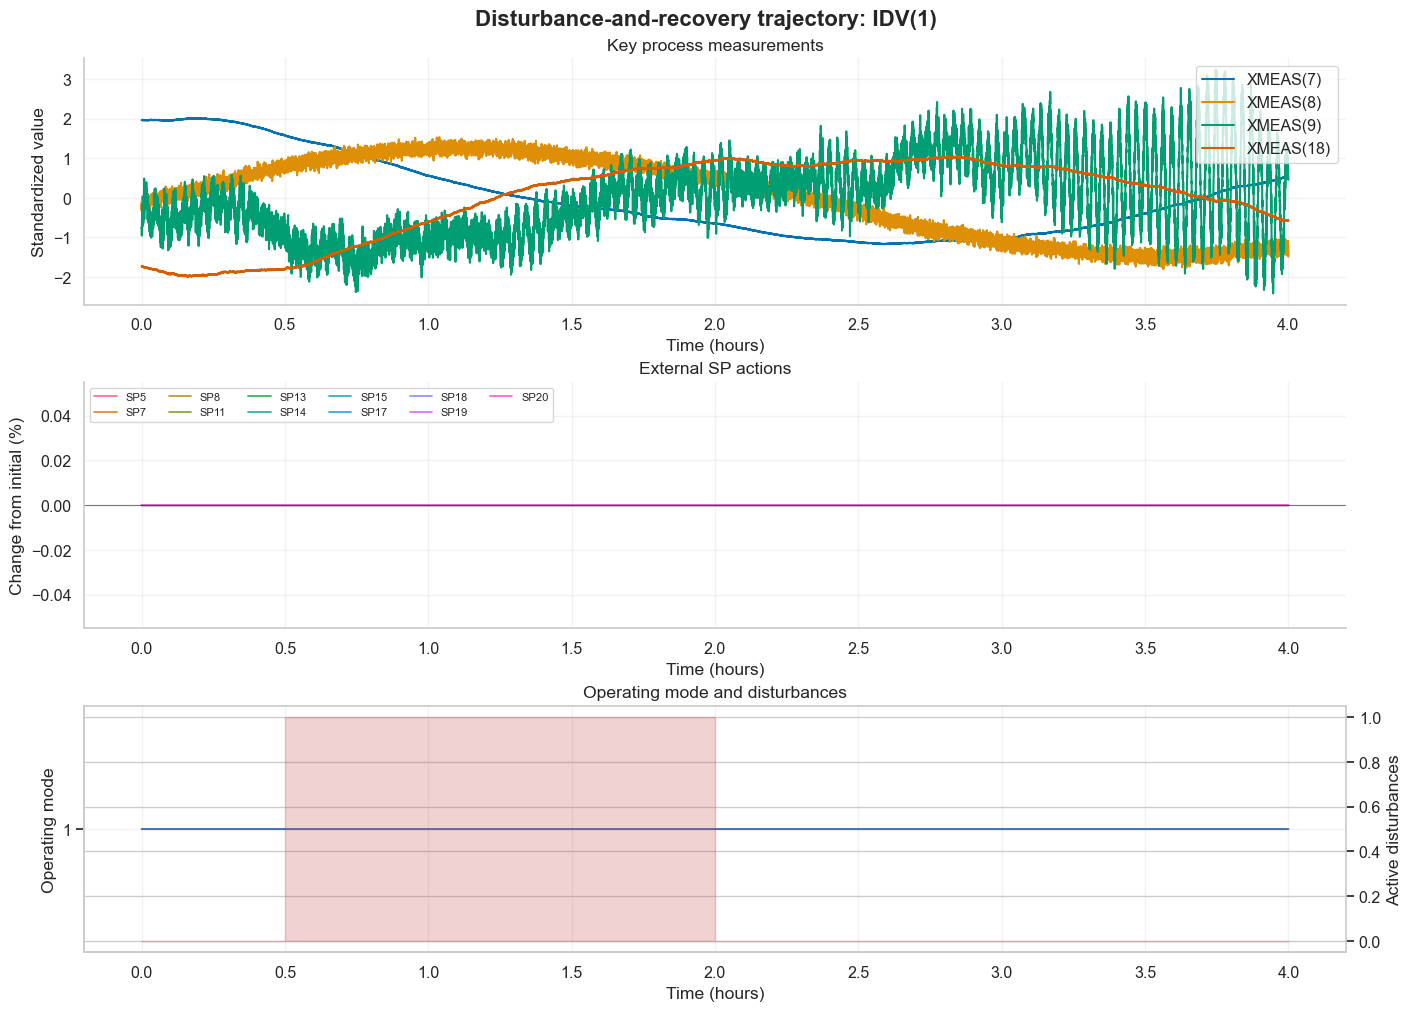

In [11]:
# 0.5小时开启IDV(1)，2小时关闭，并继续记录恢复过程。
disturbance_config = {
    **data_config,
    "warmup_hours": 3.0,
    "duration_hours": 4.0,
    "mode_events": [],
    "action_events": [],
    "disturbance_events": [
        {"time_hours": 0.50, "idv": 1, "value": 1},
        {"time_hours": 2.00, "idv": 1, "value": 0},
    ],
}
disturbance_trajectory = TEPDataGenerator(disturbance_config).generate_trajectory()
show_trajectory(
    disturbance_trajectory,
    disturbance_config,
    "Disturbance-and-recovery trajectory: IDV(1)",
)

### 5. 超限轨迹

这里将XMEAS9的训练数据软安全上限设为124°C，再通过SP18将反应器温度调至125°C。轨迹越过数据集边界但不触发TEP硬停车，用于学习可控超限过程；硬停车轨迹则在停车时保留终止前数据。

,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,action,limit_exceeded,3.0,10800,"(10801, 53)","(10800, 11)",[18],[],False


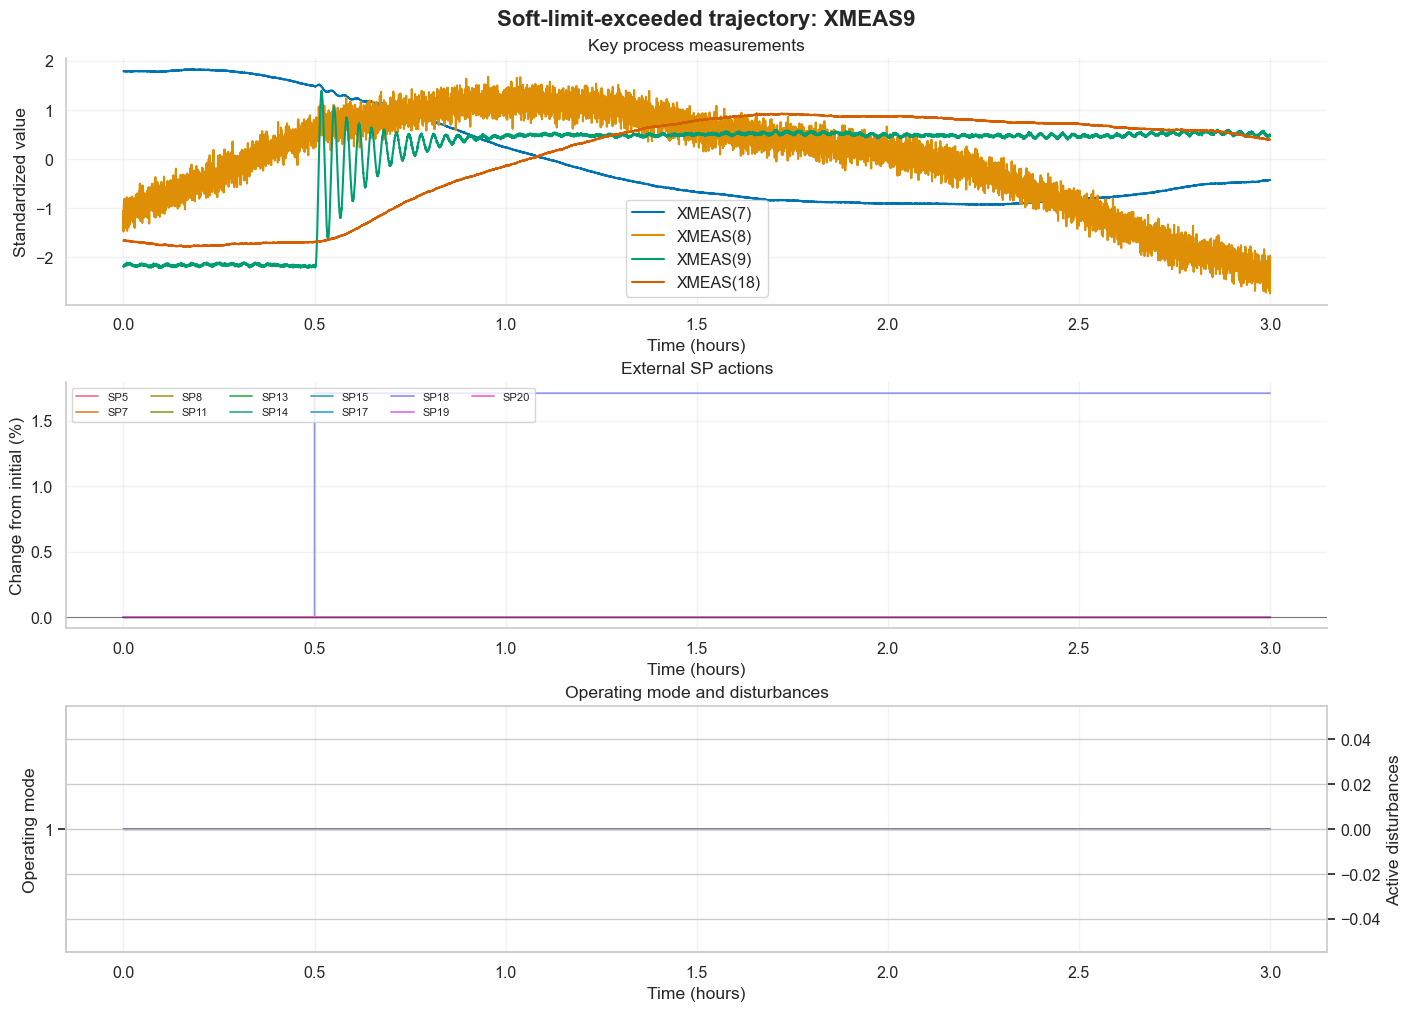

In [12]:
# 软安全边界只用于结果标注，不会主动截断仿真。
limit_exceeded_config = {
    **data_config,
    "warmup_hours": 3.0,
    "duration_hours": 3.0,
    "safety_limits": {"XMEAS9": [120.0, 124.0]},
    "mode_events": [],
    "disturbance_events": [],
    "action_events": [
        {"time_hours": 0.50, "values": {"SP18": 125.0}},
    ],
}
limit_exceeded_trajectory = TEPDataGenerator(
    limit_exceeded_config
).generate_trajectory()
show_trajectory(
    limit_exceeded_trajectory,
    limit_exceeded_config,
    "Soft-limit-exceeded trajectory: XMEAS9",
)

### 6. 反事实轨迹对比

反事实轨迹对必须具有相同的随机种子、初始工况、预热过程和记录时长，仅动作序列不同。这里将“SP保持不变”作为参考轨迹，将“0.5小时后调整SP18至124°C”作为干预轨迹；两条轨迹的差异可近似归因于该动作。

初始观测最大差异: 0.000e+00


,variable,reference final,intervention final,counterfactual difference
0,XMEAS7 reactor pressure,2433.293,2435.239,1.946
1,XMEAS8 reactor level,60.060,62.591,2.530
2,XMEAS9 reactor temperature,122.950,124.032,1.082
3,XMEAS38 product E,0.845,0.858,0.013


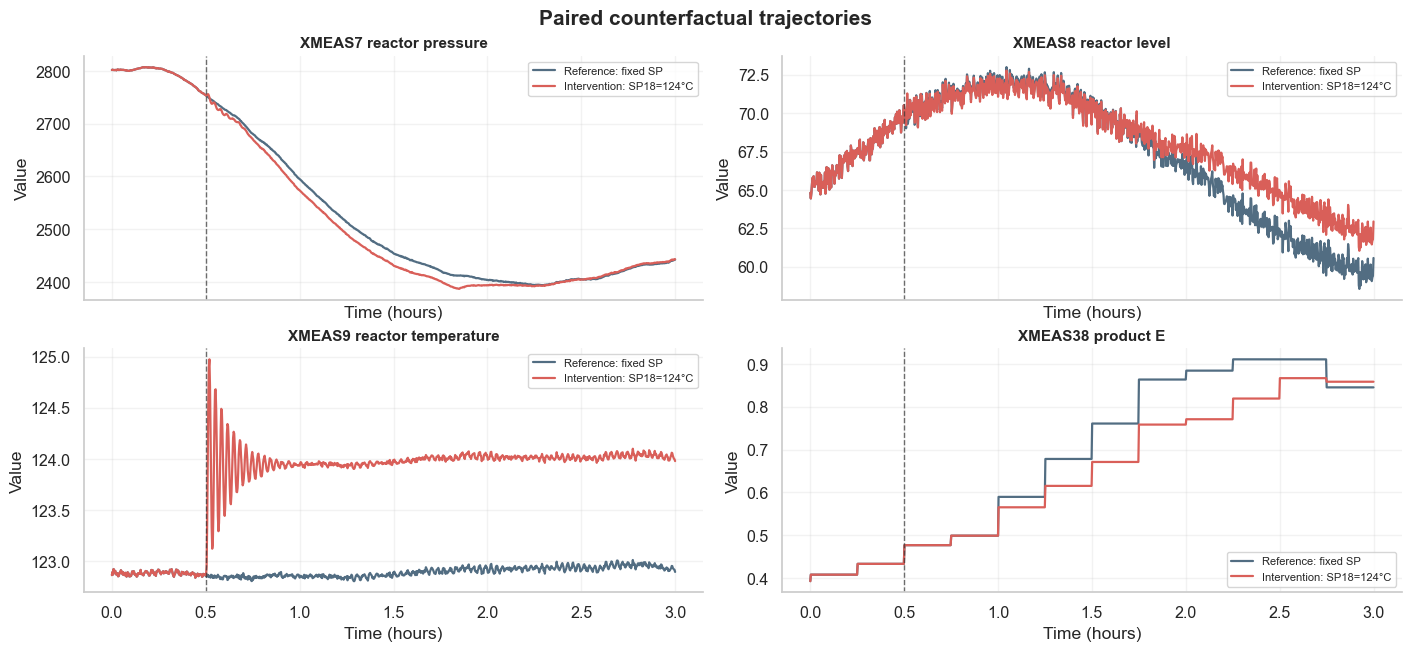

In [13]:
# 保持相同种子、工况和预热过程，仅移除动作事件作为参考。
counterfactual_reference_config = {
    **single_action_config,
    "action_events": [],
}
counterfactual_reference = TEPDataGenerator(
    counterfactual_reference_config
).generate_trajectory()
counterfactual_intervention = single_action_trajectory

counterfactual_variables = {
    "XMEAS7 reactor pressure": 6,
    "XMEAS8 reactor level": 7,
    "XMEAS9 reactor temperature": 8,
    "XMEAS38 product E": 37,
}
counterfactual_comparison, counterfactual_figure, _ = (
    plot_counterfactual_comparison(
        counterfactual_reference,
        counterfactual_intervention,
        counterfactual_variables,
        reference_label="Reference: fixed SP",
        intervention_label="Intervention: SP18=124°C",
        intervention_time_hours=0.5,
    )
)
initial_difference = counterfactual_comparison.attrs[
    "initial_observation_max_difference"
]
print(f"初始观测最大差异: {initial_difference:.3e}")
display(counterfactual_comparison.round(3))
plt.show()

### 7. 工况切换轨迹

从工况1（50/50 G/H、基础生产率）切换到工况2（10/90 G/H、基础生产率）。切换发生时不重置过程内部状态，由TEP控制器更新对应SP，并继续记录系统向新稳态过渡的完整过程。

,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,action,recovered,4.0,14400,"(14401, 53)","(14400, 11)",[18],[],False


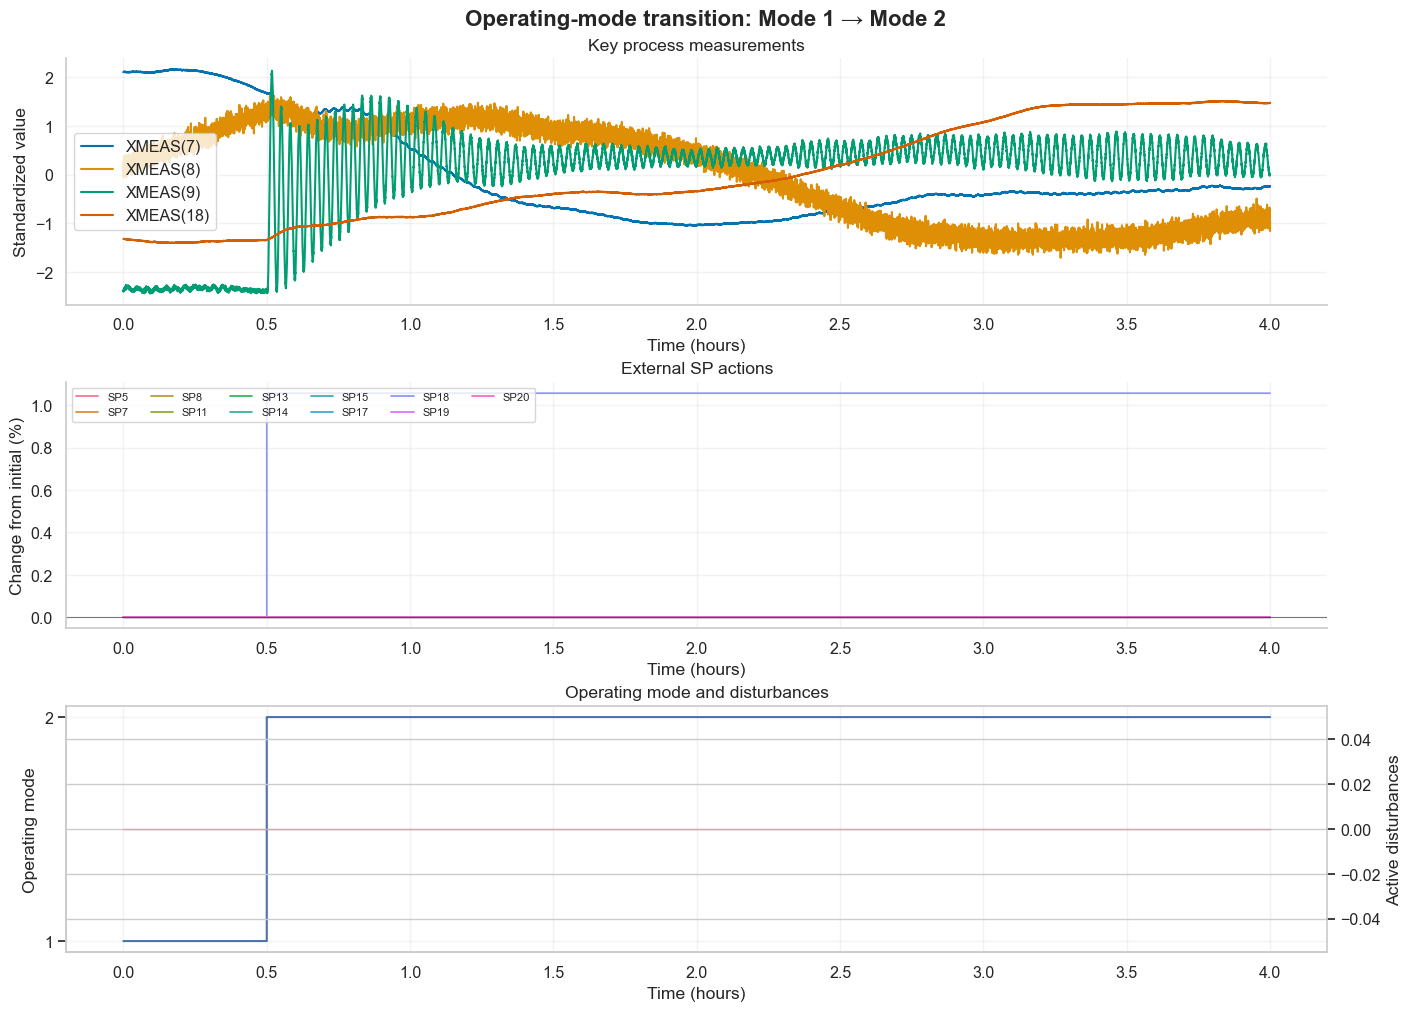

In [14]:
# 0.5小时切换预定义SP组合，物理过程状态不重置。
mode_switch_config = {
    **data_config,
    "operating_mode": 1,
    "warmup_hours": 3.0,
    "duration_hours": 4.0,
    "action_events": [],
    "disturbance_events": [],
    "mode_events": [
        {"time_hours": 0.50, "mode": 2},
    ],
}
mode_switch_trajectory = TEPDataGenerator(
    mode_switch_config
).generate_trajectory()
show_trajectory(
    mode_switch_trajectory,
    mode_switch_config,
    "Operating-mode transition: Mode 1 → Mode 2",
)

## 批量训练数据生成

批量流程分为四步：根据配置构造可复现场景计划，逐条调用 `TEPDataGenerator`，通过统一质量门后保存为独立NPZ文件，最后写出 `manifest.jsonl` 和全局覆盖摘要 `summary.json`。

`config.yaml` 默认配置用于正式生成300条基础轨迹和30个反事实对。所有轨迹使用正式的工况、时长、动作和干扰采样规则，并统一保存到 `datasets/tep_latest`；重新生成时替换旧数据，训练始终读取该目录。

当前仿真器只有一套基准稳态内部状态，因此批量正常轨迹仅从可长时间稳定预热的工况1、2、4、5开始；工况3、6应作为工况切换或越界过程单独采集，不能当作已具备对应稳态初始化的正常起点。

In [15]:
# 重新读取正式配置
data_config = load_data_config(project_root / "configs/config.yaml")

# 使用固定latest目录；完整生成时自动替换上一次数据集。
full_output_dir = project_root / data_config["output_dir"] / data_config["generation"]["dataset_name"]

# 不传数量参数，即使用config.yaml中的全量配置
full_result = generate_dataset(
    data_config,
    output_dir=full_output_dir,
    show_progress=True,
)

display(pd.DataFrame([full_result["summary"]]))
print(f"数据目录：{full_result['output_dir']}")
print(f"轨迹清单：{full_result['manifest_path']}")
print(f"统计摘要：{full_result['summary_path']}")

Generating TEP trajectories:   0%|          | 0/360 [00:00<?, ?trajectory/s]

,trajectory_count,total_transitions,total_duration_hours,scenario_counts,outcome_counts,split_counts,mode_counts,action_counts,missing_action_sp_numbers,action_coverage_ratio,idv_counts
0,360,5738995,1594.165278,"{'single_action': 60, 'fixed_sp': 45, 'multi_a...","{'recovered': 180, 'limit_exceeded': 115, 'shu...","{'train': 292, 'validation': 32, 'test': 36}","{'1': 91, '2': 91, '4': 89, '5': 89}","{'5': 75, '7': 72, '8': 88, '11': 79, '13': 79...",[],1.0,"{'1': 4, '8': 2, '5': 5, '9': 10, '2': 10, '20..."


数据目录：f:\workspace\py\llm\TWM\datasets\tep_latest
轨迹清单：f:\workspace\py\llm\TWM\datasets\tep_latest\manifest.jsonl
统计摘要：f:\workspace\py\llm\TWM\datasets\tep_latest\summary.json


## TEP-LeWM 世界模型

第一版模型复用 LeWorldModel（LeWM）的端到端联合嵌入预测思想，并针对TEP的低维连续过程数据进行适配。模型不直接处理图像，而是在潜在空间学习“当前过程状态 + SP动作 → 下一过程状态”的动力学。

| 模块 | TEP适配 | 作用 |
|---|---|---|
| 状态输入 | `XMEAS(41) + XMV(12)`，共53维 | 描述可观测过程状态 |
| 动作输入 | 11个可独立设置的SP | 描述外部控制动作 |
| 状态编码器 | MLP | 将53维状态映射为128维潜在表示 |
| 动作编码器 | LeWM Embedder | 将SP动作映射为条件表示 |
| 动力学预测器 | 动作条件因果Transformer | 根据状态—动作历史预测下一潜在状态 |
| 防坍塌约束 | SIGReg | 约束潜在表示接近各向同性高斯分布 |

1. **轨迹长度**：仿真器每秒记录一次。当前固定SP轨迹为60–180分钟，单动作轨迹为180–300分钟，多动作和干扰轨迹为240–480分钟；提前停车的轨迹以实际长度为准。
2. **轨迹切分**：训练时每60步取一个时间点。每个样本包含8分钟历史和最长30分钟未来监督，每分钟滑动一次；长度为 `D` 分钟的完整轨迹可形成 `D - 36` 个样本。
3. **一次输入**：教师强制分支使用 `observations: (9, 53)` 和 `actions: (8, 11)`；多步分支额外提供 `future_actions: (30, 11)` 与 `rollout_targets: (30, 53)`。所有变量只使用训练集统计量标准化。
4. **预测输出**：一步分支仍输出 `(B, 8, 128)`；训练批次轮换监督5、10、30分钟终点latent，验证同时计算三个时域的rollout loss。SIGReg只作为训练正则，最佳检查点由验证rollout loss选择。

In [16]:
# 建模与训练相关依赖
import subprocess
import torch
import yaml
from torch.utils.data import DataLoader

from data.data_process import TEPWindowDataset, compute_normalization
from engine.evaluation import (
    evaluate_latent_prediction,
    evaluate_planning_tasks,
    predict_latent_trajectory,
)
from engine.planning import build_cem_planner, run_tep_mpc
from engine.training import train_world_model
from models.model import build_tep_lewm
from utils.evaluation_visualization import (
    plot_latent_prediction_evaluation,
    plot_planning_case,
    plot_latent_trajectory_comparison,
)
from utils.training_visualization import plot_training_history

In [17]:
# 第一步：读取模型配置并实例化TEP-LeWM。
with open(project_root / "configs/config.yaml", encoding="utf-8") as file:
    project_config = yaml.safe_load(file)

model_config = project_config["model"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_tep_lewm(model_config).to(device)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f"运行设备：{device}")
print(f"模型参数量：{parameter_count:,}")

运行设备：cuda
模型参数量：1,557,252


### 数据预处理与DataLoader

归一化均值和标准差只从训练集计算，避免验证集信息泄漏。随后按照配置将每条轨迹切分为9个状态和8个动作组成的因果窗口，并分别构造训练与验证DataLoader。

In [18]:
# 训练始终读取配置中的latest数据集，避免时间戳目录与配置脱节。
training_config = project_config["training"]
dataset_dir = project_root / training_config["dataset_dir"]
sample_stride = int(training_config["sample_stride_steps"])

# 只根据训练轨迹计算53维状态和11维动作的标准化参数。
normalization = compute_normalization(
    dataset_dir,
    split=training_config["train_split"],
    sample_stride_steps=sample_stride,
)

dataset_options = {
    "stats": normalization,
    "history_size": model_config["history_size"],
    "rollout_horizon": max(training_config["rollout_horizons"]),
    "sample_stride_steps": sample_stride,
    "window_stride_steps": training_config["window_stride_steps"],
    "preload": training_config["preload"],
}
train_dataset = TEPWindowDataset(
    dataset_dir, training_config["train_split"], **dataset_options
)
validation_dataset = TEPWindowDataset(
    dataset_dir, training_config["validation_split"], **dataset_options
)

loader_options = {
    "batch_size": training_config["batch_size"],
    "num_workers": training_config["loader_workers"],
    "pin_memory": device.type == "cuda",
}
train_loader = DataLoader(
    train_dataset, shuffle=True, drop_last=True, **loader_options
)
validation_loader = DataLoader(
    validation_dataset, shuffle=False, drop_last=False, **loader_options
)

# 检查数据集规模以及一个真实训练批次的输入维度。
dataset_summary = pd.DataFrame(
    [train_dataset.describe(), validation_dataset.describe()],
    index=["train", "validation"],
)
display(dataset_summary)
first_batch = next(iter(train_loader))
print(f"数据目录：{dataset_dir}")
print(f"状态批次：{tuple(first_batch['observations'].shape)}")
print(f"动作批次：{tuple(first_batch['actions'].shape)}")
print(f"未来动作：{tuple(first_batch['future_actions'].shape)}")
print(f"多步目标：{tuple(first_batch['rollout_targets'].shape)}")

,trajectory_count,window_count,history_size,rollout_horizon,sample_stride_seconds
train,292,68023,8,30,60
validation,32,7372,8,30,60


数据目录：f:\workspace\py\llm\TWM\datasets\tep_latest
状态批次：(256, 9, 53)
动作批次：(256, 8, 11)
未来动作：(256, 30, 11)
多步目标：(256, 30, 53)


### 模型训练

训练接口同时支持单卡和多卡。多卡时使用DistributedDataParallel（DDP），每张GPU运行一个进程并读取不同的数据分片，损失在所有GPU间汇总，仅主进程显示进度和保存检查点。训练轮换5、10、30分钟rollout监督，验证统一计算全部时域，并以验证rollout loss选择最佳检查点；SIGReg不再参与模型选择。配置中的 `batch_size=256` 表示单卡批量大小，因此8卡训练的全局批量大小为2048。

In [19]:
# 自动使用全部可见GPU；多卡通过torchrun启动正式DDP训练。
gpu_count = torch.cuda.device_count()
print(f"可见GPU数量：{gpu_count}")

if gpu_count > 1:
    command = [
        sys.executable,
        "-m",
        "torch.distributed.run",
        "--standalone",
        f"--nproc_per_node={gpu_count}",
        str(project_root / "scripts/train.py"),
        "--config",
        str(project_root / "configs/config.yaml"),
        "--dataset-dir",
        str(dataset_dir),
        "--device",
        "cuda",
    ]
    print(f"启动{gpu_count}卡DDP训练，全局批量大小：{gpu_count * training_config['batch_size']}")
    subprocess.run(command, cwd=project_root, check=True)
    training_result = None  # 检查点由DDP主进程写入配置目录。
else:
    # 单卡或CPU环境直接调用同一个训练接口。
    training_result = train_world_model(
        project_config,
        dataset_dir=dataset_dir,
        device="cuda" if gpu_count == 1 else "cpu",
    )
    print(f"最佳检查点：{training_result['best_checkpoint']}")

可见GPU数量：1


Epoch 1/100 train:   0%|          | 0/265 [00:00<?, ?batch/s]

Epoch 1/100 validation:   0%|          | 0/29 [00:00<?, ?batch/s]

Epoch 2/100 train:   0%|          | 0/265 [00:00<?, ?batch/s]

Epoch 2/100 validation:   0%|          | 0/29 [00:00<?, ?batch/s]

...

Epoch 99/100 train:   0%|          | 0/265 [00:00<?, ?batch/s]

Epoch 99/100 validation:   0%|          | 0/29 [00:00<?, ?batch/s]

Epoch 100/100 train:   0%|          | 0/265 [00:00<?, ?batch/s]

Epoch 100/100 validation:   0%|          | 0/29 [00:00<?, ?batch/s]

最佳检查点：checkpoints\tep_lewm_multistep_v2\best.pt


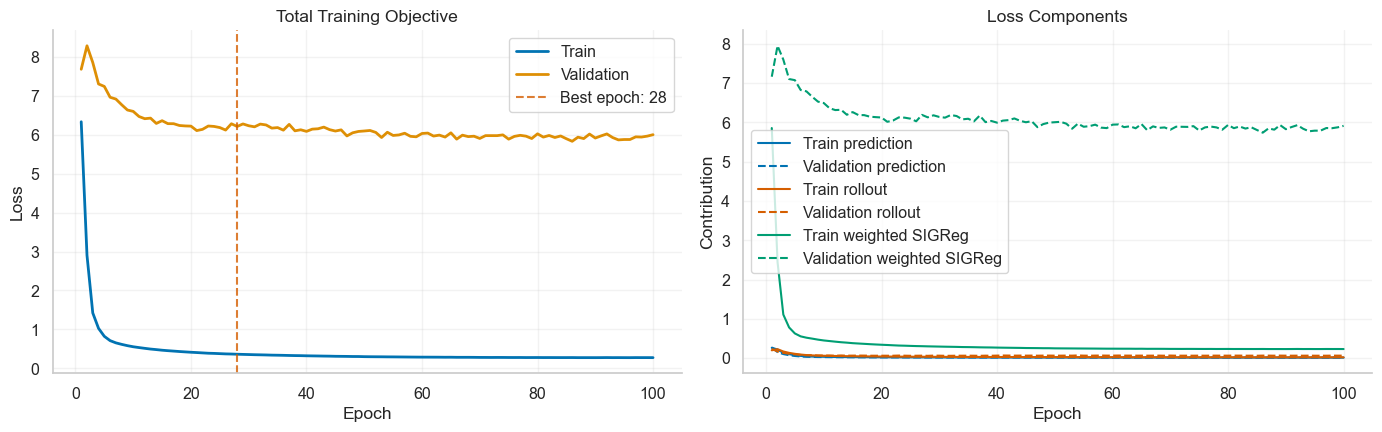

,best_epoch,checkpoint_metric,best_checkpoint_metric,best_validation_loss,best_validation_prediction_loss
0,28,validation_rollout_loss,0.062479,6.210383,0.020768


In [20]:
# 自动读取训练历史、绘制损失并返回最佳模型信息。
training_summary, _, _ = plot_training_history(
    training_config["output_dir"],
    sigreg_weight=training_config["sigreg_weight"],
    search_roots=[project_root, project_root / "tutorial"],
)
plt.show()
display(pd.DataFrame([training_summary]))

## 状态推演评估

在测试集的单动作和多动作轨迹上，使用真实动作序列进行latent状态推演。`horizon=1`对应单步预测，其余时域采用自回归滚动；评价指标为预测latent与真实状态latent之间的MSE。

Latent rollout evaluation:   0%|          | 0/17 [00:00<?, ?batch/s]

检查点epoch：28
评估窗口数：4,325


,scenario_type,horizon,latent_mse_mean,latent_mse_median,latent_mse_std,window_count
0,overall,1,0.028812,0.023763,0.021607,4325
1,overall,5,0.044800,0.034120,0.039770,4325
2,overall,10,0.069403,0.048061,0.062632,4325
3,overall,30,0.175844,0.102342,0.176239,4325
4,multi_action,1,0.030650,0.026058,0.022683,3628
5,multi_action,5,0.048487,0.037975,0.042073,3628
6,multi_action,10,0.076714,0.056740,0.065527,3628
7,multi_action,30,0.199127,0.133356,0.182861,3628
8,single_action,1,0.019248,0.017022,0.010483,697
9,single_action,5,0.025605,0.023593,0.012709,697


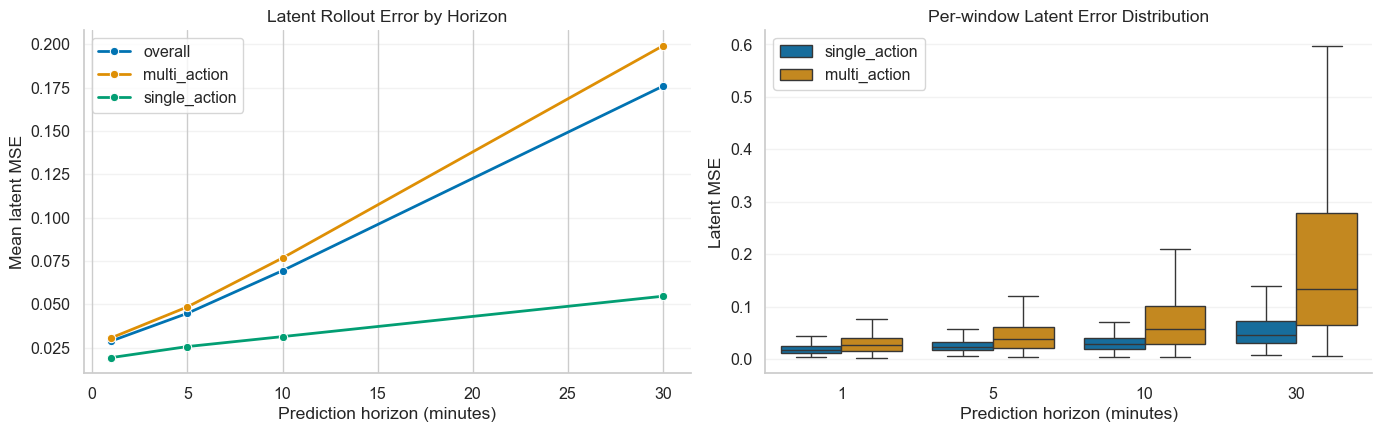

In [21]:
# 定位训练得到的最佳检查点。
checkpoint_relative = Path(training_config["output_dir"]) / "best.pt"
checkpoint_path = next(path for path in [
    checkpoint_relative,
    project_root / checkpoint_relative,
    project_root / "tutorial" / checkpoint_relative,
] if path.is_file())

# horizon=1为单步预测，更长时域为自回归latent推演。
latent_evaluation = evaluate_latent_prediction(
    checkpoint_path,
    dataset_dir,
    sample_stride_steps=training_config["sample_stride_steps"],
    window_stride_steps=training_config["window_stride_steps"],
    device=str(device),
    **project_config["evaluation"],
)

print(f"检查点epoch：{latent_evaluation['checkpoint_epoch']}")
print(f"评估窗口数：{latent_evaluation['window_count']:,}")
display(latent_evaluation["summary"].round(6))
plot_latent_prediction_evaluation(latent_evaluation)
plt.show()

轨迹：traj_000089
最终latent MSE：0.075260


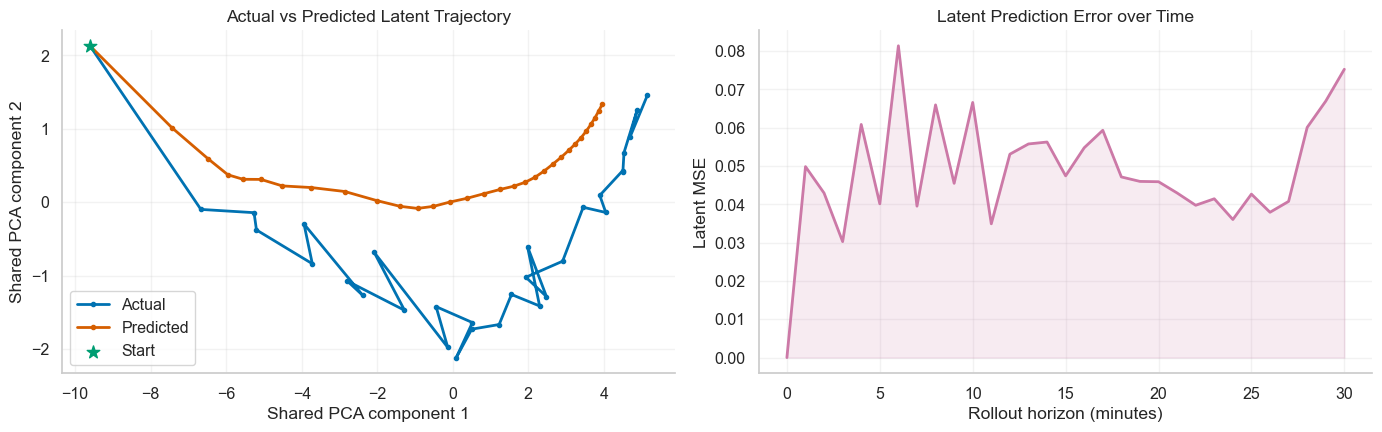

In [22]:
# 选择动作事件附近的一条多动作测试轨迹，对比真实与预测latent轨迹。
latent_trajectory = predict_latent_trajectory(
    checkpoint_path,
    dataset_dir,
    split=project_config["evaluation"]["split"],
    scenario_type="multi_action",
    horizon=max(project_config["evaluation"]["horizons"]),
    sample_stride_steps=training_config["sample_stride_steps"],
    device=str(device),
)

print(f"轨迹：{latent_trajectory['trajectory_id']}")
print(f"最终latent MSE：{latent_trajectory['latent_mse'][-1]:.6f}")
plot_latent_trajectory_comparison(latent_trajectory)
plt.show()

## 任务规划评估

从测试集单动作和多动作轨迹的首个动作时刻出发，将30分钟后的真实状态作为可达目标。CEM仍以终点latent误差为主要目标，但搜索被限制为稀疏、分段保持且幅度受限的SP动作，以匹配训练数据；MPC每5分钟重新规划并在真实TEP仿真器中执行。过程未停机且最终标准化XMEAS MSE不超过固定阈值0.10，记为规划成功；相对改善率仅作为辅助诊断指标。

In [23]:
# 批量执行测试任务，并统计整体及不同动作场景的成功率。
planning_evaluation = evaluate_planning_tasks(
    checkpoint_path,
    dataset_dir,
    project_config,
    device=str(device),
)

print("规划评估汇总：")
display(planning_evaluation["summary"].round(4))
print("逐任务结果：")
display(planning_evaluation["per_task"].round(4))

CEM-MPC planning evaluation:   0%|          | 0/16 [00:00<?, ?task/s]

规划评估汇总：


,scenario_type,task_count,success_rate,shutdown_rate,initial_xmeas_mse,final_xmeas_mse,mean_improvement,success_mse_threshold
0,overall,15,0.3333,0.0667,0.4975,0.2889,0.1920,0.1
1,multi_action,12,0.3333,0.0833,0.5289,0.3179,0.1028,0.1
2,single_action,3,0.3333,0.0000,0.3717,0.1729,0.5490,0.1


逐任务结果：


,trajectory_id,scenario_type,initial_xmeas_mse,final_xmeas_mse,improvement,success,alive
0,traj_000134,multi_action,0.4078,1.2654,-2.1032,False,False
1,traj_000298,multi_action,0.7271,0.1143,0.8428,False,True
2,traj_000198,multi_action,0.5788,0.2425,0.5810,False,True
3,traj_000181,multi_action,0.2383,0.0971,0.5926,True,True
4,traj_000162,multi_action,0.6110,0.0354,0.9421,True,True
5,traj_000099,multi_action,0.1630,0.3087,-0.8946,False,True
6,traj_000048,single_action,0.3198,0.2411,0.2459,False,True
7,traj_000210,multi_action,0.5112,0.0367,0.9282,True,True
8,traj_000119,multi_action,0.2009,0.0786,0.6086,True,True
9,traj_000092,single_action,0.5426,0.2363,0.5645,False,True


轨迹：traj_000252 (single_action)
规划成功：True
XMEAS误差改善：83.66%


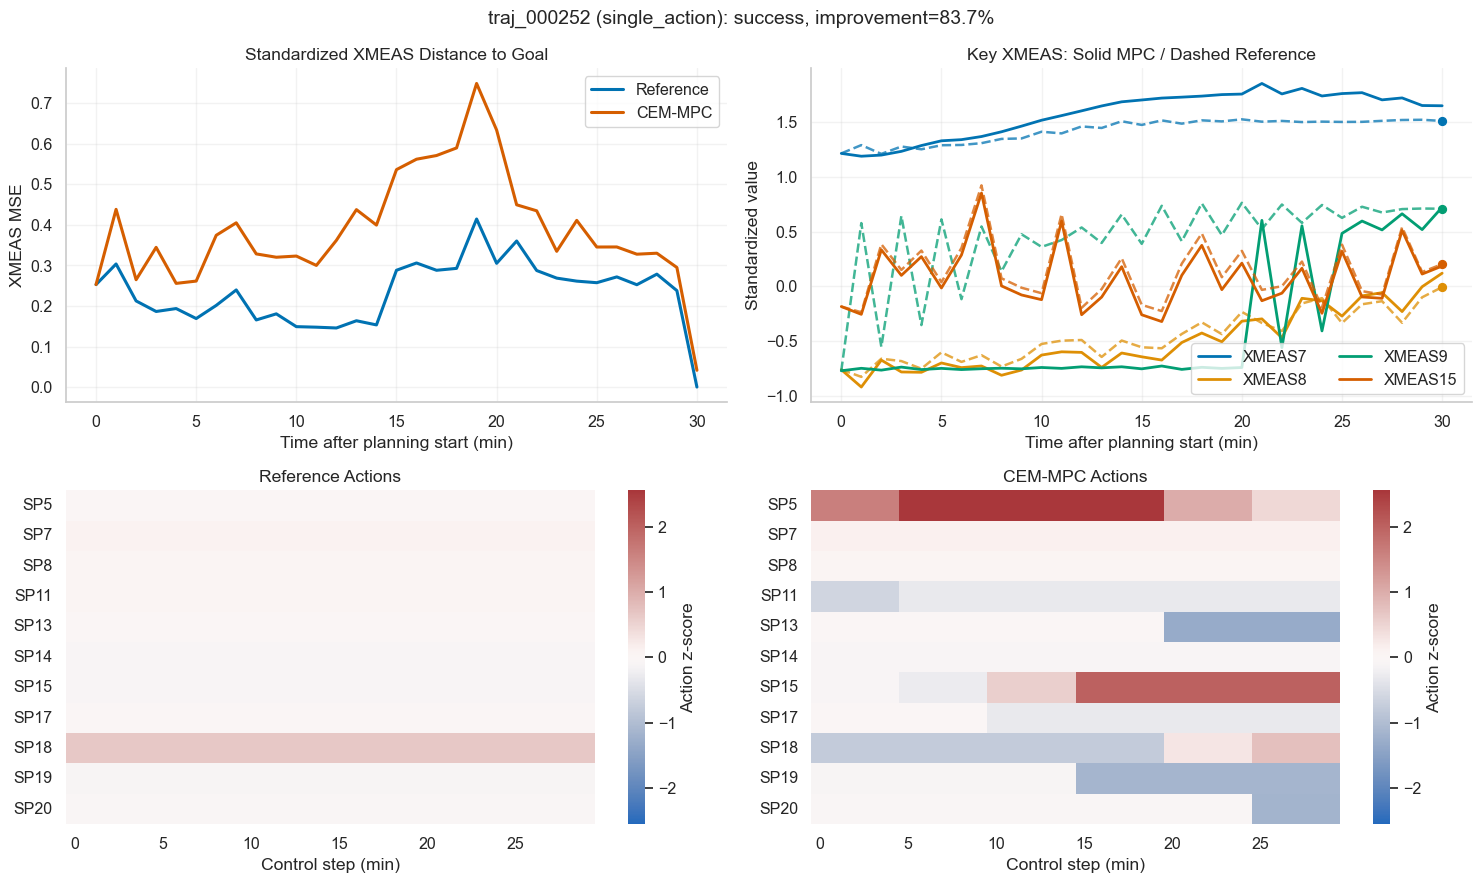

In [24]:
# 优先选择成功任务中改善程度居中的代表性案例；若均失败，则选择最具代表性的失败案例。
planning_case = planning_evaluation["typical_case"]
print(f"轨迹：{planning_case['trajectory_id']} ({planning_case['scenario_type']})")
print(f"规划成功：{planning_case['success']}")
print(f"XMEAS误差改善：{planning_case['improvement']:.2%}")
plot_planning_case(planning_case)
plt.show()

轨迹：traj_000198 (multi_action)
规划存活：True
最终XMEAS MSE：0.2425
XMEAS误差改善：58.10%


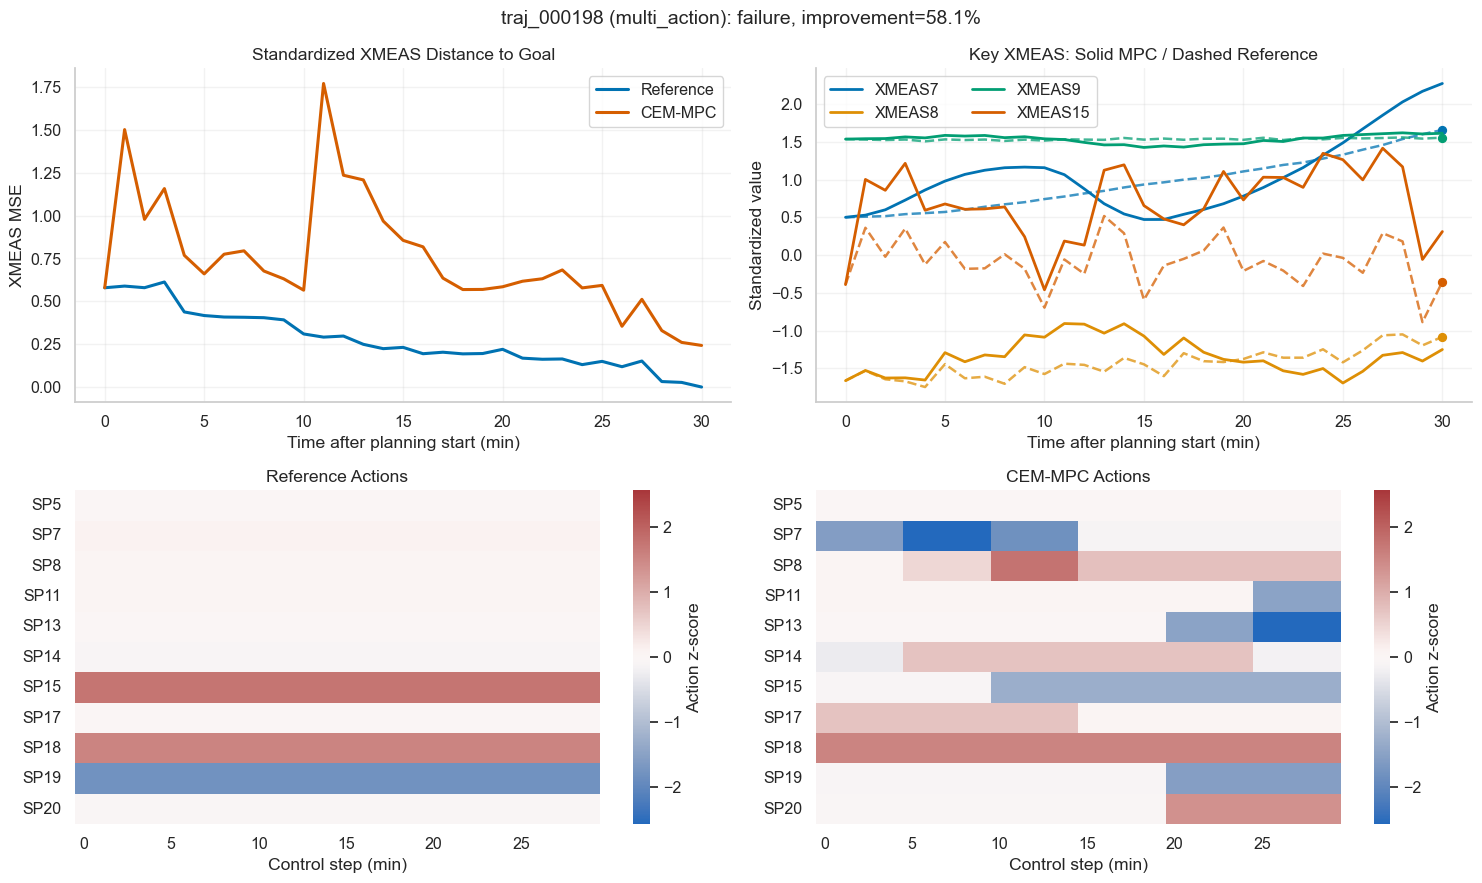

In [25]:
# 选择终点误差接近失败样本中位数的案例，观察典型失败模式。
failed_cases = [case for case in planning_evaluation["cases"] if not case["success"]]
if not failed_cases:
    print("当前评估中没有失败案例。")
else:
    failure_median = np.median([case["final_xmeas_mse"] for case in failed_cases])
    failed_planning_case = min(
        failed_cases, key=lambda case: abs(case["final_xmeas_mse"] - failure_median)
    )
    print(f"轨迹：{failed_planning_case['trajectory_id']} ({failed_planning_case['scenario_type']})")
    print(f"规划存活：{failed_planning_case['alive']}")
    print(f"最终XMEAS MSE：{failed_planning_case['final_xmeas_mse']:.4f}")
    print(f"XMEAS误差改善：{failed_planning_case['improvement']:.2%}")
    plot_planning_case(failed_planning_case)
    plt.show()